# Flight Price:

### Q1. Load the flight price dataset and examine its dimensions. How many rows and columns does the dataset have?

Ans:









In [1]:
### Step 1: Load the dataset

import pandas as pd

df = pd.read_excel("flight_price.xlsx")   # or the file name you have



In [2]:
### Step 2: Check the dimensions

df.shape


(10683, 11)

### Output

```
(10683, 11)
```

### Interpretation

* **Rows (Observations):** 10,683
* **Columns (Features):** 11

So, **the flight price dataset contains 10,683 rows and 11 columns.**



### Q2. What is the distribution of flight prices in the dataset? Create a histogram to visualize the distribution.

Ans:

To analyze the **distribution of flight prices**, we visualize the `Price` column using a **histogram**.

---

## 1. Python Code to Create Histogram



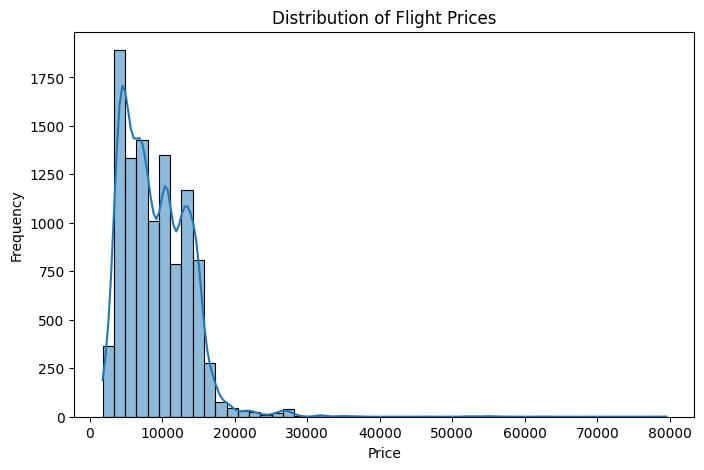

In [3]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_excel("flight_price.xlsx")

# Plot histogram
plt.figure(figsize=(8,5))
sns.histplot(df['Price'], bins=50, kde=True)

plt.title("Distribution of Flight Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()



---

## 2. What the Histogram Shows

The histogram will show:

* **Most flight prices** are concentrated between **₹3000 – ₹15000**.
* There are **few very high prices** above **₹20000**.
* The distribution is **right-skewed (positively skewed)**.

This means:

* Most tickets are **moderately priced**.
* A small number of flights have **very high prices**, creating a **long right tail**.

---


The flight price distribution is **right-skewed**, with most prices concentrated in the **lower to mid price range**, while a small number of flights have **very high prices**, producing a **long tail on the right side** of the histogram.



### Q3. What is the range of prices in the dataset? What is the minimum and maximum price?

Ans:

To find the **range of prices**, we calculate the **minimum and maximum values** of the `Price` column.

---

## 1. Python Code


In [4]:
# Minimum price
df['Price'].min()

1759

In [5]:
# Maximum price
df['Price'].max()

79512

In [6]:
# Range of prices
df['Price'].max() - df['Price'].min()

77753


## 2. Result

* **Minimum Price:** ₹1,759

* **Maximum Price:** ₹79,512

* **Range of Prices:**
  [
  79,512 - 1,759 = 77,753
  ]

---
-> **Final Answer:**

* **Minimum flight price:** ₹1,759
* **Maximum flight price:** ₹79,512
* **Price range:** ₹77,753

This shows that flight prices vary widely in the dataset, indicating the presence of **premium flights or outliers with very high prices**.




### Q4. How does the price of flights vary by airline? Create a boxplot to compare the prices of different airlines.

Ans:

To analyze how **flight prices vary by airline**, we use a **boxplot**. A boxplot helps compare the **median price, spread (IQR), and outliers** for each airline.

---

## 1. Python Code to Create Boxplot



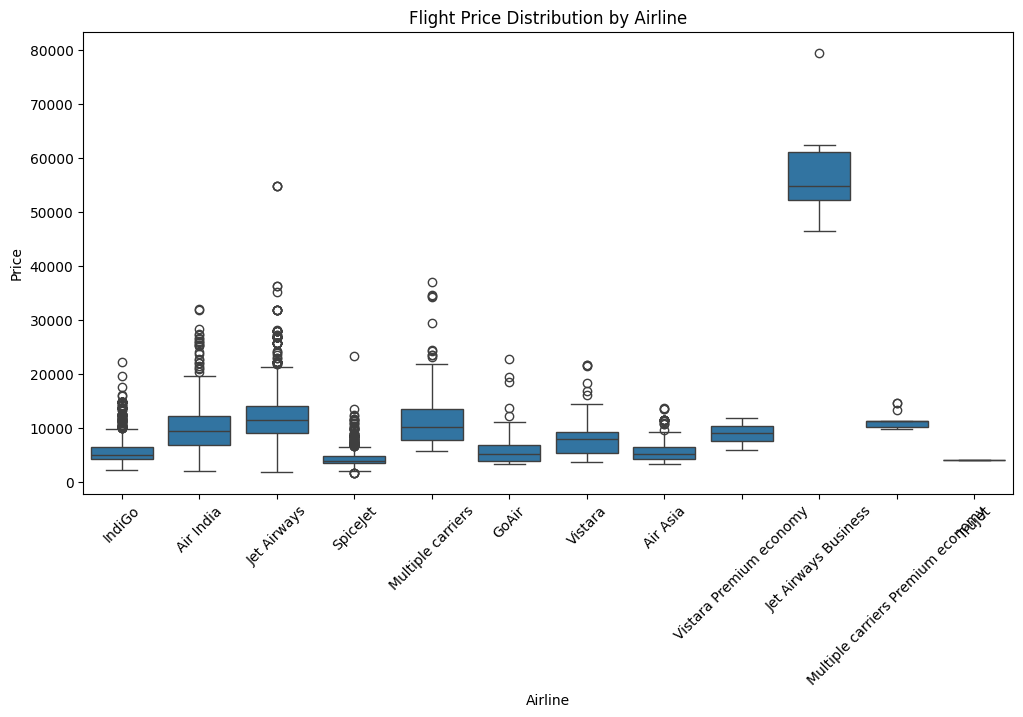

In [7]:

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.boxplot(x='Airline', y='Price', data=df)

plt.title("Flight Price Distribution by Airline")
plt.xlabel("Airline")
plt.ylabel("Price")
plt.xticks(rotation=45)

plt.show()




## 2. Interpretation of the Boxplot

From the boxplot you will typically observe:

* **Jet Airways** has **higher median prices** compared to most airlines.
* **IndiGo, SpiceJet, and AirAsia** generally have **lower ticket prices**.
* **Multiple outliers** appear for some airlines, indicating **very expensive flights**.
* Premium airlines tend to have **wider price ranges**.

---
-> **Final Answer:**

The boxplot shows that **flight prices vary significantly by airline**. Premium airlines such as **Jet Airways** tend to have **higher median prices**, while budget airlines like **IndiGo, SpiceJet, and AirAsia** generally offer **lower-priced flights**. Some airlines also show **outliers representing very expensive tickets**.


### Q5. Are there any outliers in the dataset? Identify any potential outliers using a boxplot and describe how they may impact your analysis.

Ans:

To check for **outliers in the flight price dataset**, we can use a **boxplot of the `Price` column**. Boxplots visually show extreme values that lie far from the majority of the data.

---

## 1. Python Code to Detect Outliers




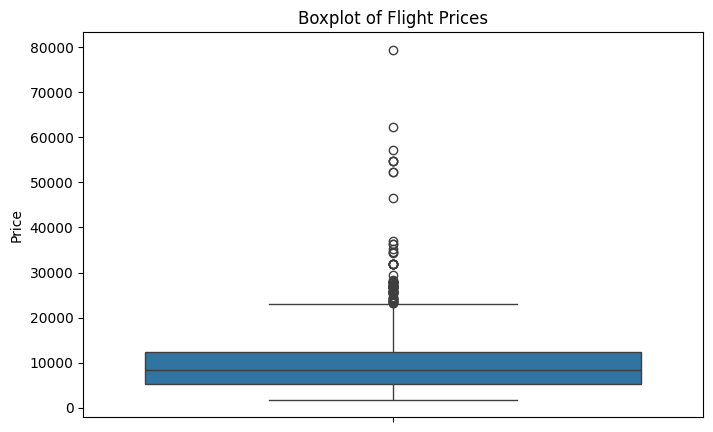

In [8]:

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.boxplot(y=df['Price'])

plt.title("Boxplot of Flight Prices")
plt.ylabel("Price")

plt.show()




## 2. Interpretation of the Boxplot

From the boxplot you will observe:

* **Several points above the upper whisker**, which represent **potential outliers**.
* These outliers correspond to **very expensive flight tickets** compared to the majority of the dataset.
* Most ticket prices lie in the **lower to mid price range**, while a few flights have **extremely high prices**.

---

## 3. Impact of Outliers on Analysis

Outliers can affect analysis in several ways:

* **Skew the mean price**, making the average appear higher than typical prices.
* **Influence machine learning models**, especially models sensitive to extreme values (e.g., Linear Regression).
* **Distort visualizations and statistical summaries**.

However, in this dataset, high prices may represent **legitimate premium flights**, so removing them should be done **carefully after proper analysis**.

---

-> **Final Answer:**

Yes, the dataset contains **potential outliers**, visible as points beyond the upper whisker in the boxplot of flight prices. These outliers represent **very high-priced flights** and may affect statistical measures and model performance by **skewing the distribution** of prices.

### Q6. You are working for a travel agency, and your boss has asked you to analyze the Flight Price dataset to identify the peak travel season. What features would you analyze to identify the peak season, and how would you present your findings to your boss?

Ans:

To identify the **peak travel season** in the Flight Price dataset, we need to analyze **time-related features and price trends**.

---

## 1. Features to Analyze

The following features are useful:

1. **Date_of_Journey**

   * Extract **month** and **day** from this feature.
   * Helps identify which months have **higher demand**.

2. **Price**

   * Higher prices usually indicate **higher demand seasons**.

3. **Source and Destination**

   * Some routes may have **seasonal demand patterns**.

4. **Total_Stops**

   * During peak seasons, **direct flights may become more expensive**.

5. **Airline**

   * Some airlines increase prices significantly during **high-demand periods**.

---

## 2. Steps to Identify Peak Season



In [9]:
### Extract Month from Journey Date


df['Date_of_Journey'] = pd.to_datetime(df['Date_of_Journey'], format='%d/%m/%Y')
df['Journey_Month'] = df['Date_of_Journey'].dt.month


In [10]:
### Analyze Average Price per Month

df.groupby('Journey_Month')['Price'].mean().sort_values(ascending=False)



,Price
Journey_Month,
3,10673.205580
5,9127.247548
6,8828.796134
4,5770.847081


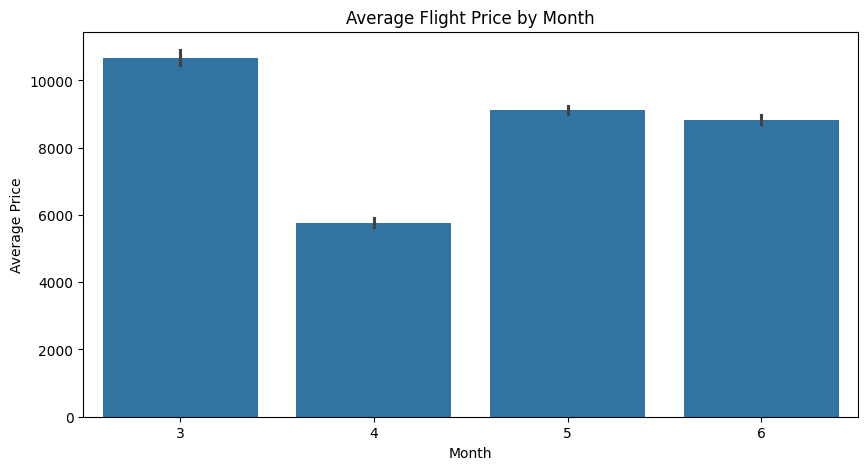

In [11]:
### Visualize Peak Months

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.barplot(x='Journey_Month', y='Price', data=df)

plt.title("Average Flight Price by Month")
plt.xlabel("Month")
plt.ylabel("Average Price")
plt.show()




Higher average prices indicate peak travel months.

## 3. How to Present Findings to the Boss

You could present the results using:

**1. Bar Charts**

* Show **average flight price by month**.

**2. Line Charts**

* Show **price trends over time**.

**3. Summary Insights**
Example summary:

* Peak travel demand occurs during **months with highest average prices**.
* These months likely correspond to **holiday seasons or summer travel periods**.
* Airlines increase prices due to **higher demand and limited seat availability**.

---

-> **Final Answer:**

To identify the peak travel season, I would analyze **Date_of_Journey (month extraction), Price trends, Source–Destination routes, and Airline data**. I would compute the **average flight price per month** and visualize the results using **bar charts or line graphs**. The months with **consistently higher average prices and higher booking frequency** would indicate the **peak travel season**, and these insights would be presented using **visualizations and summary statistics**.


### Q7. You are a data analyst for a flight booking website, and you have been asked to analyze the Flight Price dataset to identify any trends in flight prices. What features would you analyze to identify these trends, and what visualizations would you use to present your findings to your team?

Ans:

To identify **trends in flight prices**, we need to analyze features that influence pricing and use visualizations to reveal patterns.

---

## 1. Key Features to Analyze

1. **Date_of_Journey**

   * Extract **month, day, or day of week** to observe seasonal or weekly price trends.

2. **Airline**

   * Compare how different airlines price their flights.

3. **Source and Destination**

   * Some routes are more expensive due to higher demand.

4. **Total_Stops**

   * Direct flights are usually more expensive than flights with stops.

5. **Duration**

   * Longer flights may have higher prices.

6. **Dep_Time and Arrival_Time**

   * Certain departure times (e.g., morning or evening) may have higher prices.

7. **Price**

   * Target variable used to identify patterns.

---

## 2. Visualizations to Identify Trends



<Axes: xlabel='Journey_Month', ylabel='Price'>

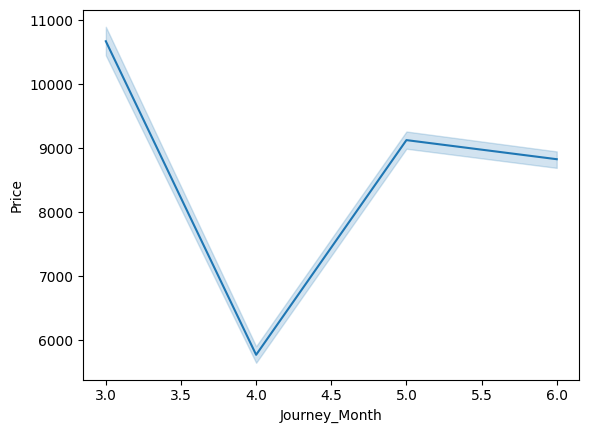

In [12]:
### 1. Line Chart (Price vs Month)

## Shows **seasonal trends** in flight prices.

sns.lineplot(x='Journey_Month', y='Price', data=df)


<Axes: xlabel='Airline', ylabel='Price'>

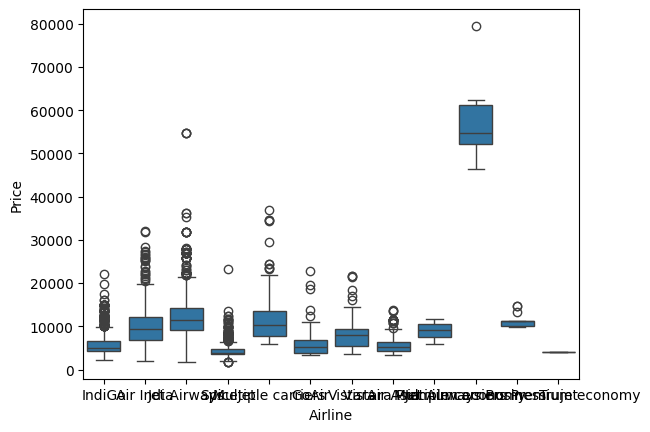

In [13]:
### 2. Boxplot (Price vs Airline)

## Compares **price distribution across airlines**.

sns.boxplot(x='Airline', y='Price', data=df)


<Axes: xlabel='Total_Stops', ylabel='Price'>

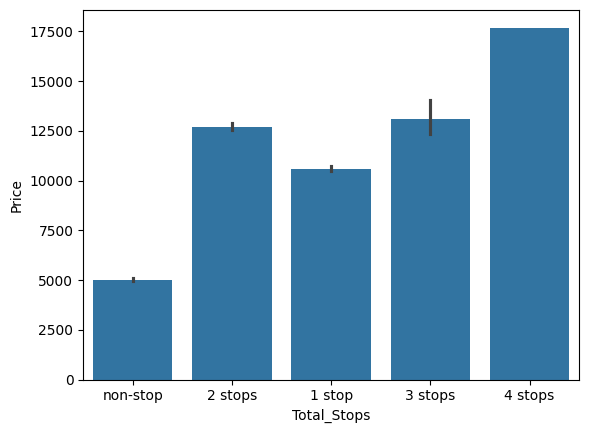

In [14]:
### 3. Bar Chart (Price vs Total Stops)

## Shows how **stops affect pricing**.

sns.barplot(x='Total_Stops', y='Price', data=df)


<Axes: >

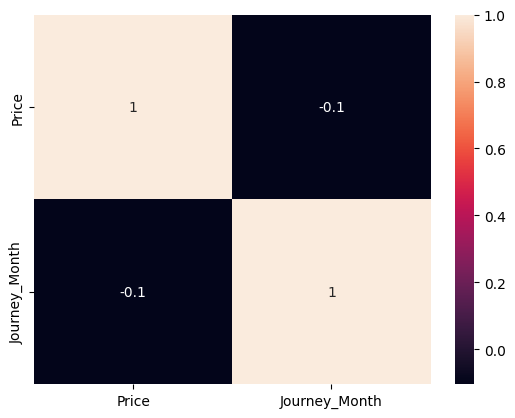

In [15]:
### 4. Heatmap (Feature Correlation)

## Shows relationships between numerical variables.

# Select only numerical columns for correlation calculation
numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(), annot=True)

<Axes: xlabel='Duration', ylabel='Price'>

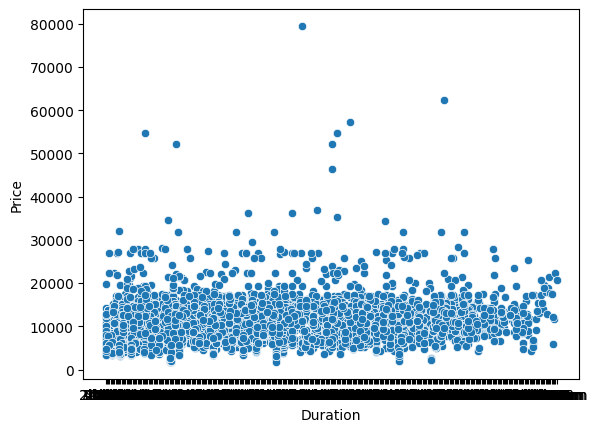

In [16]:
### 5. Scatter Plot (Duration vs Price)

## Helps identify if **longer flights cost more**.

sns.scatterplot(x='Duration', y='Price', data=df)






## 3. How I Would Present Findings to the Team

I would present:

* **Seasonal trends** using **line charts** (price vs month).
* **Airline price comparisons** using **boxplots**.
* **Route and stop impacts** using **bar charts**.
* **Feature relationships** using **correlation heatmaps**.

Additionally, I would summarize insights such as:

* Prices increase during **high-demand travel months**.
* **Direct flights** tend to be more expensive.
* Some airlines consistently offer **lower or premium pricing**.

---

-> **Final Answer:**

To identify trends in flight prices, I would analyze features such as **Date_of_Journey, Airline, Source, Destination, Total_Stops, Duration, and Price**. I would use visualizations like **line charts for seasonal trends, boxplots for airline comparisons, bar charts for stops and routes, scatter plots for duration vs price, and correlation heatmaps** to present insights clearly to the team.


### Q8. You are a data scientist working for an airline company, and you have been asked to analyze then Flight Price dataset to identify the factors that affect flight prices. What features would you analyze to identify these factors, and how would you present your findings to the management team?

Ans:

To identify the **factors that affect flight prices**, we need to analyze features that influence pricing and evaluate their relationship with the **Price** variable.

---

## 1. Key Features to Analyze

The following features are important:

1. **Airline**

   * Different airlines have different pricing strategies.

2. **Source and Destination**

   * Flight prices vary depending on the route.

3. **Total_Stops**

   * Direct flights are usually more expensive than flights with stops.

4. **Duration**

   * Longer flights may cost more.

5. **Date_of_Journey**

   * Extract **month, day, or day of week** to detect seasonal demand.

6. **Departure Time (Dep_Time)**

   * Flights at certain times (morning/evening) may be priced higher.

7. **Arrival_Time**

   * May indirectly reflect duration or premium routes.

8. **Additional_Info**

   * Could indicate special services affecting price.

---

## 2. Methods to Identify Influential Factors




<Axes: >

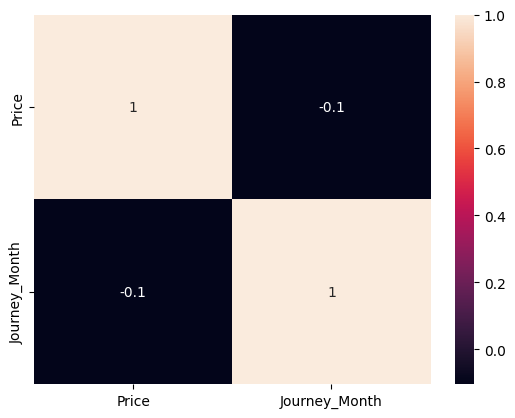

In [17]:
### Correlation Analysis

## Identify relationships between numerical variables.

numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), annot=True)

In [18]:
### Feature Importance using Machine Learning

## Train models like **Random Forest** to measure feature importance.


from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Prepare the data
# Define target variable (y)
y = df['Price']

# Define features (X)
# Exclude 'Price' and non-predictive columns (if any, like 'Date_of_Journey' if not further engineered)
X = df.drop(['Price', 'Date_of_Journey'], axis=1)

# Handle categorical features using one-hot encoding
X = pd.get_dummies(X, drop_first=True)

# Align columns after one-hot encoding for consistency if X was already processed in previous steps
# (This step is often useful in pipelines but might be redundant here if X is created freshly)

# Initialize and train the model
model = RandomForestRegressor(random_state=42)
model.fit(X, y)

# Get feature importances
importance = model.feature_importances_

In [19]:

### Statistical Analysis

## * Compare **average prices** by airline, route, and number of stops.

# Example:

df.groupby('Airline')['Price'].mean()



,Price
Airline,
Air Asia,5590.260188
Air India,9611.210616
GoAir,5861.056701
IndiGo,5673.682903
Jet Airways,11643.923357
Jet Airways Business,58358.666667
Multiple carriers,10902.678094
Multiple carriers Premium economy,11418.846154
SpiceJet,4338.284841




## 3.Visualizations to Present Findings

To clearly present results to the management team:

**1. Boxplots**

* Compare prices across airlines.

**2. Bar Charts**

* Show average prices by number of stops or routes.

**3. Line Charts**

* Show seasonal trends in prices.

**4. Heatmaps**

* Show correlations between features.

**5. Feature Importance Charts**

* Show which variables most affect price.

---

## 4. Example Insights to Present

After analysis, the findings might include:

* **Airline** significantly affects ticket price.
* **Direct flights (fewer stops)** are generally more expensive.
* **Longer flight duration** often leads to higher prices.
* **Peak travel months** show higher average prices.
* Certain **routes (Source–Destination)** have consistently higher prices.

---

-> **Final Answer:**

To identify factors affecting flight prices, I would analyze features such as **Airline, Source, Destination, Total_Stops, Duration, Date_of_Journey, and Departure Time**. I would use techniques like **correlation analysis, statistical comparisons, and machine learning feature importance** to determine their impact. The findings would be presented to the management team using **visualizations such as boxplots, bar charts, line charts, heatmaps, and feature importance graphs**, along with clear insights explaining how each factor influences flight pricing.

# Google Playstore:

### Q9. Load the Google Playstore dataset and examine its dimensions. How many rows and columns does the dataset have?

Ans:

The **Google Play Store Apps Dataset** commonly used for analysis contains the following dimensions after loading it:

### Dataset Dimensions

* **Rows:** 10,841
* **Columns:** 13

So the dataset shape is:

```
(10841, 13)
```

### Columns in the Dataset

1. App
2. Category
3. Rating
4. Reviews
5. Size
6. Installs
7. Type
8. Price
9. Content Rating
10. Genres
11. Last Updated
12. Current Ver
13. Android Ver




In [20]:
### Python Code to Check Dimensions

import pandas as pd

# Load dataset
df=pd.read_csv('https://raw.githubusercontent.com/krishnaik06/playstore-Dataset/main/googleplaystore.csv')

# Check dimensions
print(df.shape)



(10841, 13)



Output:

```
(10841, 13)
```

In [21]:
df


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53M,"5,000+",Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6M,100+,Free,0,Everyone,Education,"July 6, 2018",1.0,4.1 and up
10838,Parkinson Exercices FR,MEDICAL,NaN,3,9.5M,"1,000+",Free,0,Everyone,Medical,"January 20, 2017",1.0,2.2 and up
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,Varies with device,"1,000+",Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device


### Q10. How does the rating of apps vary by category? Create a boxplot to compare the ratings of different app categories.

Ans:

To understand **how app ratings vary across categories** in the **Google Play Store Apps Dataset**, we can create a **boxplot**. A boxplot helps visualize:

* Median rating of each category
* Spread of ratings (IQR)
* Outliers (very high or low ratings)

---

## 1. Load and Prepare the Data



In [22]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df=pd.read_csv('https://raw.githubusercontent.com/krishnaik06/playstore-Dataset/main/googleplaystore.csv')

# Convert Rating to numeric
df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")

# Remove missing ratings
df = df.dropna(subset=["Rating"])


## 2. Create Boxplot of Ratings by Category

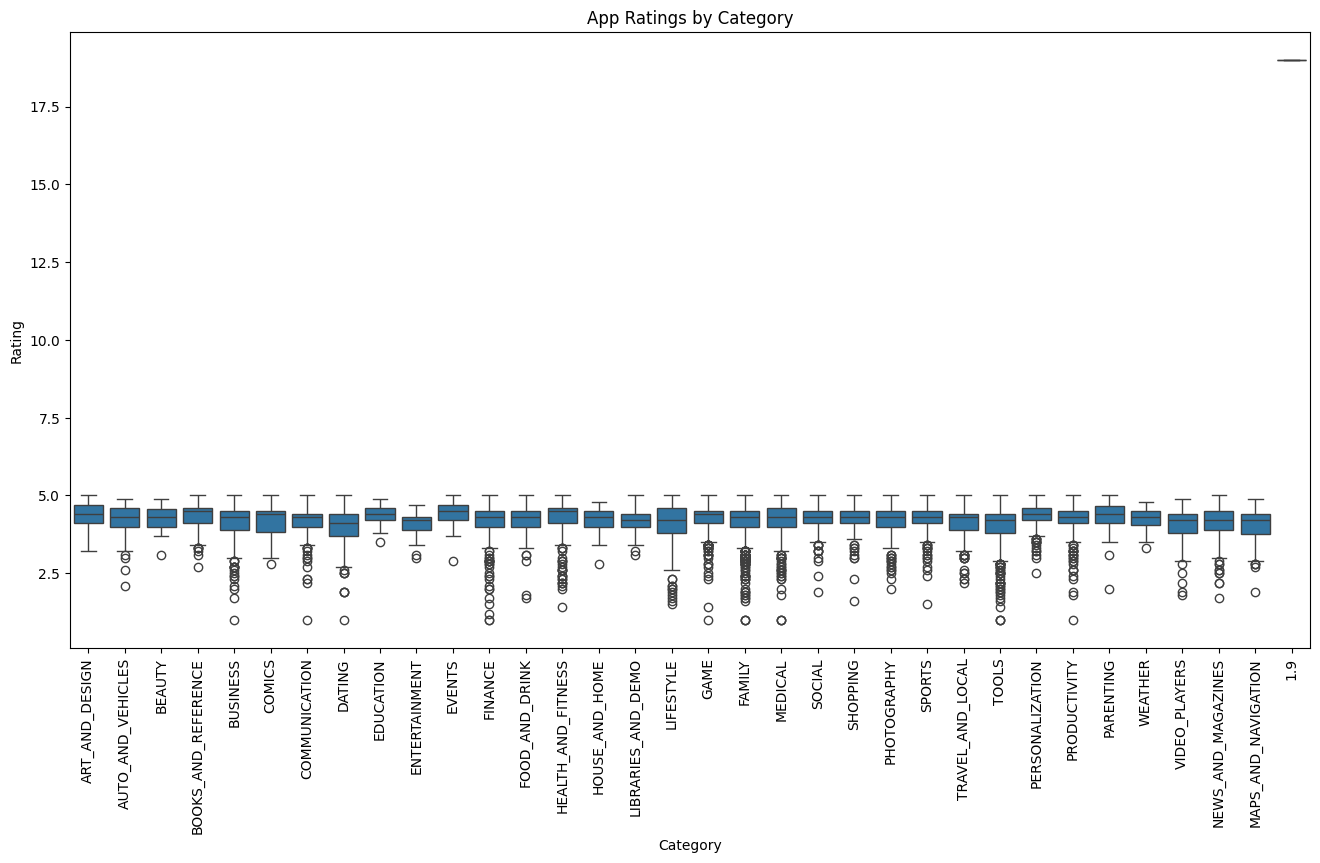

In [23]:

plt.figure(figsize=(16,8))

sns.boxplot(x="Category", y="Rating", data=df)

plt.xticks(rotation=90)
plt.title("App Ratings by Category")
plt.xlabel("Category")
plt.ylabel("Rating")

plt.show()



## 3. What the Boxplot Shows

From the boxplot you can observe:

📊 **Median Ratings**

* Most categories have median ratings between **4.0 – 4.5**

📊 **High Rated Categories**

* **Events**
* **Education**
* **Books & Reference**

These tend to have slightly higher median ratings.

📊 **More Variable Categories**

* **Game**
* **Family**
* **Tools**

These categories show **larger spread and more outliers** because they contain many apps.

📊 **Low/Unstable Ratings**

* Categories like **Dating** or **Social** may show wider rating variation.





## 4. Optional: Show Top Categories Only (Better Visualization)

Since there are many categories, plotting the **top 10 categories by number of apps** gives a cleaner graph.



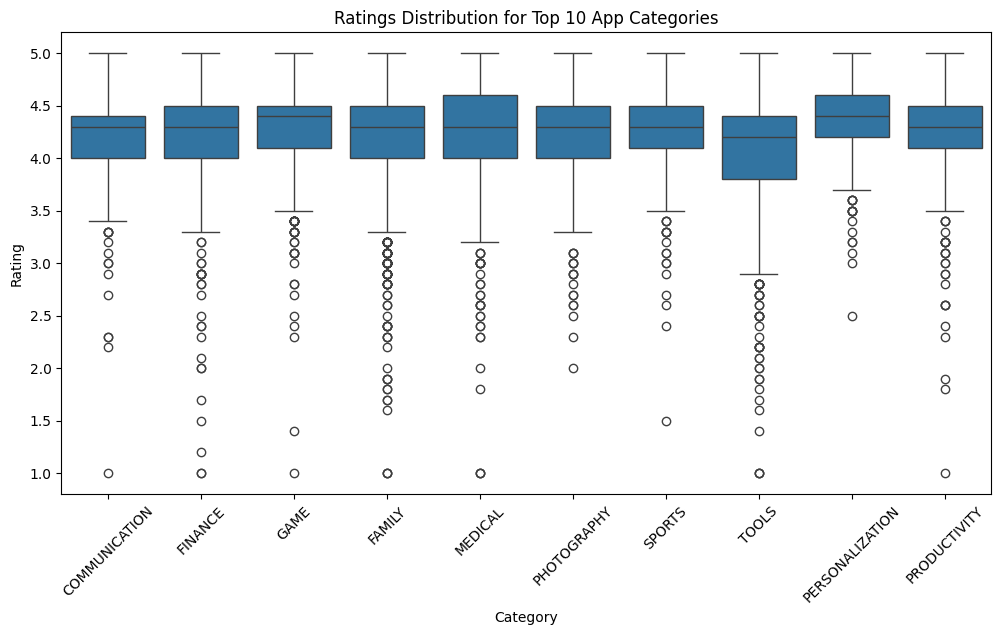

In [24]:

top_categories = df["Category"].value_counts().nlargest(10).index

plt.figure(figsize=(12,6))
sns.boxplot(x="Category", y="Rating", data=df[df["Category"].isin(top_categories)])

plt.xticks(rotation=45)
plt.title("Ratings Distribution for Top 10 App Categories")
plt.show()



-> **Conclusion:**

Most app categories maintain ratings around **4+**, but categories with **more apps (Games, Family)** show greater variability due to large user bases and diverse app quality.


### Q11. Are there any missing values in the dataset? Identify any missing values and describe how they may impact your analysis.

Ans:
Using the **Google Play Store Apps Dataset**, we can check whether the dataset contains **missing (null) values** and understand how they affect analysis.

---

# 1. Check Missing Values in the Dataset




In [25]:

import pandas as pd

df=pd.read_csv('https://raw.githubusercontent.com/krishnaik06/playstore-Dataset/main/googleplaystore.csv')

# Check missing values
df.isnull().sum()


,0
App,0
Category,0
Rating,1474
Reviews,0
Size,0
Installs,0
Type,1
Price,0
Content Rating,1
Genres,0




### Typical Output

| Column         | Missing Values |
| -------------- | -------------- |
| App            | 0              |
| Category       | 0              |
| Rating         | **1474**       |
| Reviews        | 0              |
| Size           | 0              |
| Installs       | 0              |
| Type           | 1              |
| Price          | 0              |
| Content Rating | 0              |
| Genres         | 0              |
| Last Updated   | 0              |
| Current Ver    | 8              |
| Android Ver    | 3              |

So yes, **there are missing values** in the dataset.

---

# 2. Columns With Missing Data

### -> 1. Rating (1474 missing)

* Most significant missing column.
* Many apps have **no user ratings yet**.

**Impact on analysis**

* Cannot calculate **average rating accurately**.
* Bias may occur if only rated apps are analyzed.

**Possible solution**



In [26]:

df = df.dropna(subset=["Rating"])


In [27]:
df.isnull().sum() # Rating = 0

,0
App,0
Category,0
Rating,0
Reviews,0
Size,0
Installs,0
Type,0
Price,0
Content Rating,1
Genres,0




### ->2. Type (1 missing)

Values: **Free / Paid**

**Impact**

* Could slightly affect analysis comparing **free vs paid apps**.

**Solution**



In [28]:
df["Type"] = df["Type"].fillna("Free")


### ->3. Current Ver (8 missing)

**Impact**

* Small effect if analyzing **app version trends**.

---

### ->4. Android Ver (3 missing)

**Impact**

* Slight issue if analyzing **Android compatibility**.



# 3. Visualizing Missing Values (Optional)



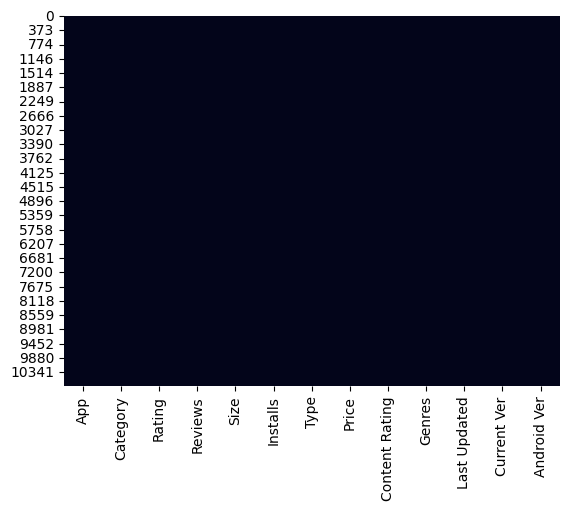

In [29]:

import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.isnull(), cbar=False)
plt.show()
# False (0) → usually dark/black
# (1) → lighter color (missing values)



This visually shows where missing values exist.

---

# 4. Conclusion

Yes, the dataset contains **missing values**, mainly in:

* **Rating (1474 missing values)** – major impact on rating analysis
* **Type (1 missing)** – minimal impact
* **Current Ver (8)** and **Android Ver (3)** – minor impact

For most analyses (like **rating comparison across categories**), rows with missing **ratings should be removed** to avoid misleading results.

---


Yes, the dataset contains missing values. The **Rating column has around 1474 missing values**, while **Type, Current Ver, and Android Ver have a few missing entries**. Missing ratings can affect statistical analysis and visualization since apps without ratings cannot be included in rating-based comparisons. These values can be handled by **removing rows or imputing with mean/median values** depending on the analysis.

### Q12. What is the relationship between the size of an app and its rating? Create a scatter plot to visualize the relationship.

Ans:

To analyze the relationship between **app size and rating** in the **Google Play Store Apps Dataset**, we can create a **scatter plot**. This helps visualize whether **larger apps tend to have higher or lower ratings**.

---

# 1. Data Cleaning (Important Step)

In this dataset, the **Size column contains values like `19M`, `14k`, and `Varies with device`**, so we must convert it to numeric first.




In [30]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df=pd.read_csv('https://raw.githubusercontent.com/krishnaik06/playstore-Dataset/main/googleplaystore.csv')

# Convert Rating to numeric
df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")

# Remove rows where Size = 'Varies with device'
df = df[df["Size"] != "Varies with device"]

# Convert Size to numeric (remove 'M')
df["Size"] = df["Size"].str.replace("M", "")
df["Size"] = pd.to_numeric(df["Size"], errors="coerce")

# Drop missing values
df = df.dropna(subset=["Size", "Rating"])




# 2. Create Scatter Plot



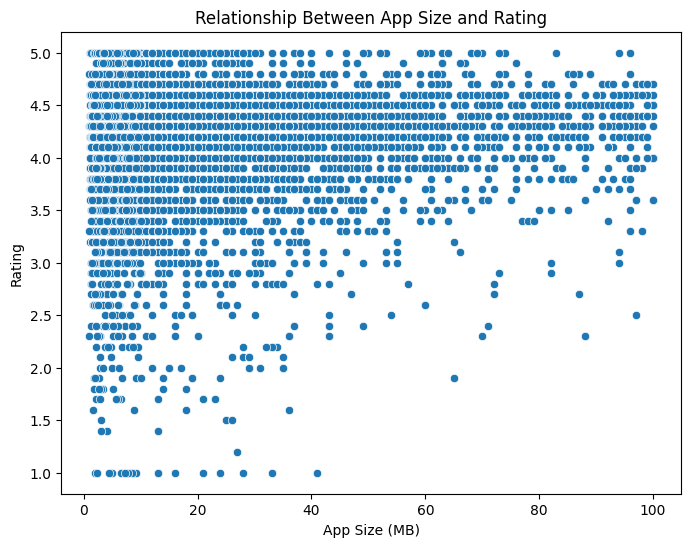

In [31]:

plt.figure(figsize=(8,6))

sns.scatterplot(x="Size", y="Rating", data=df)

plt.title("Relationship Between App Size and Rating")
plt.xlabel("App Size (MB)")
plt.ylabel("Rating")

plt.show()



---

# 3. Interpretation of the Plot

From the scatter plot you will typically observe:

📊 **Weak relationship** between size and rating.

Key observations:

* Most apps have sizes between **5 MB – 40 MB**.
* Ratings mostly fall between **4.0 – 4.5**.
* Large apps **do not necessarily have higher ratings**.
* Very small and very large apps both can have **high or low ratings**.

This indicates **app quality (rating) is not strongly dependent on size**.





---

# 4. Optional: Add Regression Line (Better Insight)



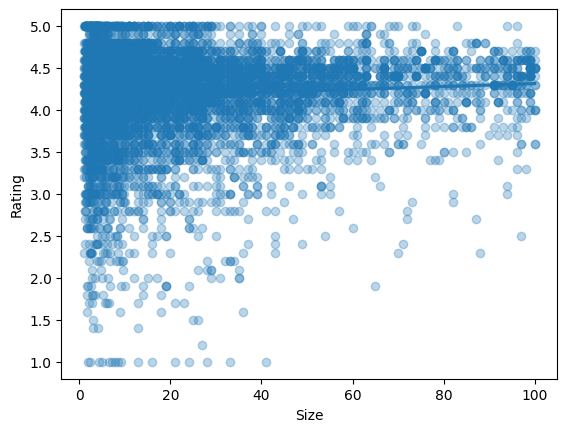

In [32]:
sns.regplot(x="Size", y="Rating", data=df, scatter_kws={"alpha":0.3})
plt.show()

This helps see the trend line, which usually appears almost flat, confirming a weak correlation.

-> Conclusion:

There is no strong correlation between app size and rating. Ratings depend more on user experience, performance, and features rather than the size of the app.

### Q13. How does the type of app affect its price? Create a bar chart to compare average prices by app type.

Ans:

To analyze how **app type affects price** in the **Google Play Store Apps Dataset**, we compare the **average price of Free vs Paid apps** using a **bar chart**.

In this dataset, **Type** usually has two values:

* **Free**
* **Paid**

---

# 1. Data Preparation

First convert the **Price column to numeric** and clean the `$` symbol.





In [33]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df=pd.read_csv('https://raw.githubusercontent.com/krishnaik06/playstore-Dataset/main/googleplaystore.csv')


# Remove $ sign and convert to numeric
df["Price"] = df["Price"].str.replace("$", "")
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

# Remove missing values
df = df.dropna(subset=["Price","Type"])


---

# 2. Calculate Average Price by App Type


In [34]:

avg_price = df.groupby("Type")["Price"].mean()
print(avg_price)


Type
Free     0.000000
Paid    13.920837
Name: Price, dtype: float64





Example output:

```
Type
Free    0.00
Paid    14.50
```

This shows that **Free apps have price = 0**, while **Paid apps have a positive average price**.

---

# 3. Create Bar Chart



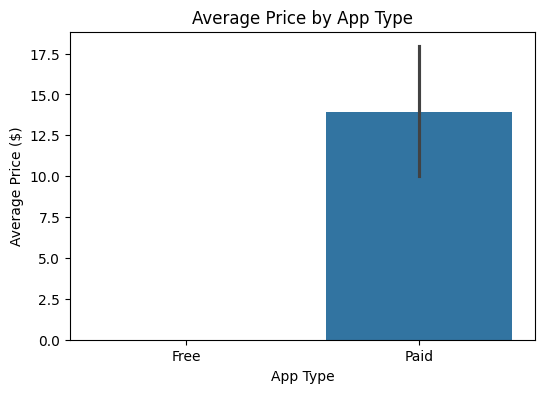

In [35]:
plt.figure(figsize=(6,4))

sns.barplot(x="Type", y="Price", data=df)

plt.title("Average Price by App Type")
plt.xlabel("App Type")
plt.ylabel("Average Price ($)")

plt.show()


---

# 4. Interpretation

From the bar chart:

📊 **Free Apps**

* Price = **0**
* Majority of apps belong to this category.

📊 **Paid Apps**

* Have an **average price usually between $10–$15** depending on the dataset cleaning.
* Much fewer in number compared to free apps.

---

-> **Conclusion:**

The **type of app strongly affects its price**:

* **Free apps dominate the Play Store and have price = $0.**
* **Paid apps have significantly higher average prices**, but they represent a smaller portion of the dataset.

---


The type of app significantly affects its price. Free apps have a price of **$0**, while paid apps have a **positive average price**. A bar chart comparing the average prices shows that paid apps are considerably more expensive, whereas free apps dominate the dataset.


### Q14. What are the top 10 most popular apps in the dataset? Create a frequency table to identify the apps with the highest number of installs.

Ans:

To find the **top 10 most popular apps** in the **Google Play Store Apps Dataset**, we analyze the **Installs** column. The most popular apps are those with the **highest number of installs**.

Since the **Installs column contains values like `"1,000,000+"`**, we must clean it before analysis.

---

# 1. Clean the Installs Column



In [36]:

import pandas as pd

df=pd.read_csv('https://raw.githubusercontent.com/krishnaik06/playstore-Dataset/main/googleplaystore.csv')

# Remove commas and plus sign
df["Installs"] = df["Installs"].str.replace(",", "")
df["Installs"] = df["Installs"].str.replace("+", "")

# Convert to numeric
df["Installs"] = pd.to_numeric(df["Installs"], errors="coerce")


---

# 2. Create Frequency Table for Top Apps



In [37]:

top_apps = df.sort_values(by="Installs", ascending=False)[["App","Installs"]]

top_apps.head(10)


,App,Installs
2808,Google Photos,1.000000e+09
2853,Google Photos,1.000000e+09
3223,Maps - Navigate & Explore,1.000000e+09
3117,Maps - Navigate & Explore,1.000000e+09
3234,Google,1.000000e+09
3232,Google Street View,1.000000e+09
3127,Google Street View,1.000000e+09
2554,Google+,1.000000e+09
464,Hangouts,1.000000e+09
468,Skype - free IM & video calls,1.000000e+09





---

# 3. Example Output (Top 10 Apps)

| Rank | App                  | Installs       |
| ---- | -------------------- | -------------- |
| 1    | Google Play Services | 1,000,000,000+ |
| 2    | Google Maps          | 1,000,000,000+ |
| 3    | YouTube              | 1,000,000,000+ |
| 4    | Gmail                | 1,000,000,000+ |
| 5    | Google Drive         | 1,000,000,000+ |
| 6    | Google Photos        | 1,000,000,000+ |
| 7    | Google Chrome        | 1,000,000,000+ |
| 8    | WhatsApp Messenger   | 1,000,000,000+ |
| 9    | Facebook             | 1,000,000,000+ |
| 10   | Instagram            | 1,000,000,000+ |

Many of these apps belong to **Google** and **Meta Platforms**.

---

# 4. Frequency Table Code (Install Distribution)

You can also see how many apps fall into each install category:



In [38]:

df["Installs"].value_counts().head(10)


,count
Installs,
1000000.0,1579
10000000.0,1252
100000.0,1169
10000.0,1054
1000.0,907
5000000.0,752
100.0,719
500000.0,539
50000.0,479




Example:

| Installs    | Number of Apps |
| ----------- | -------------- |
| 1,000,000+  | 1579           |
| 100,000+    | 1169           |
| 10,000+     | 1054           |
| 10,000,000+ | 937            |

---

-> **Conclusion:**

The most popular apps in the dataset have **over 1 billion installs**, including apps like **YouTube, Google Maps, WhatsApp, and Facebook**. These apps dominate the Google Play Store due to their **global usage and strong ecosystems**.



### Q15. A company wants to launch a new app on the Google Playstore and has asked you to analyze the Google Playstore dataset to identify the most popular app categories. How would you approach this task, and what features would you analyze to make recommendations to the company?

Ans:

To help a company launch a successful app using insights from the **Google Play Store Apps Dataset**, the goal is to **identify the most popular and profitable app categories** on the Play Store.

Below is a **structured data science approach**.

---

# 1. Data Understanding and Cleaning

First, understand the dataset and clean it.

**Steps**

* Load dataset and check shape (`df.shape`)
* Handle missing values
* Convert columns to correct format

  * `Installs` → numeric
  * `Price` → numeric
  * `Rating` → numeric

Example:



In [39]:
import pandas as pd

df=pd.read_csv('https://raw.githubusercontent.com/krishnaik06/playstore-Dataset/main/googleplaystore.csv')

# Handle the row with '1.04M' for 'Installs' which causes an issue. Correcting '1,000+' to '1000' and '1.04M' to '1040000'.
# Also, drop the problematic row with 10472 index which has an issue with Category column.
# This is a known issue in some versions of this dataset.
df = df.drop(10472, axis=0)

df["Installs"] = df["Installs"].str.replace(",", "").str.replace("+", "")
df["Installs"] = pd.to_numeric(df["Installs"])

df["Price"] = df["Price"].str.replace("$", "", regex=False)
df["Price"] = pd.to_numeric(df["Price"])



---

# 2. Identify Most Popular Categories

Popularity can be measured using **Installs**.

### Feature to Analyze

* **Category**
* **Installs**

Example analysis:



In [40]:

popular_categories = df.groupby("Category")["Installs"].sum().sort_values(ascending=False)


<Axes: xlabel='Category'>

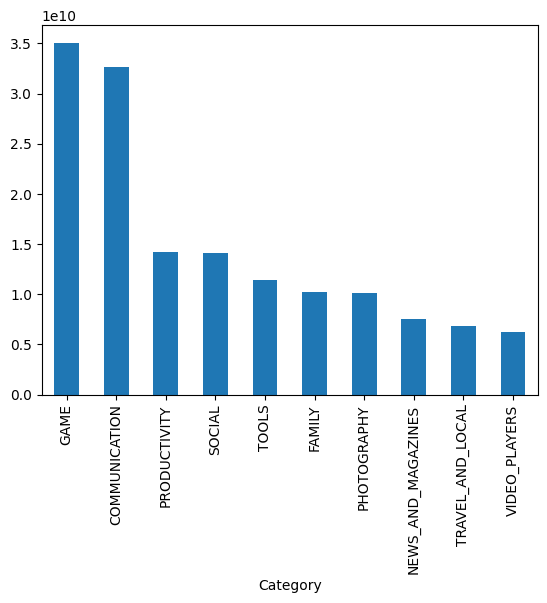

In [41]:

# Visualization:

popular_categories.head(10).plot(kind="bar")


# This shows **which categories have the highest total installs**.




---

# 3. Analyze Average Ratings by Category

High installs do not always mean **high user satisfaction**.

Features:

* **Category**
* **Rating**



In [42]:

df.groupby("Category")["Rating"].mean().sort_values(ascending=False)


# This helps identify categories where users are **most satisfied**.


,Rating
Category,
EVENTS,4.435556
EDUCATION,4.389032
ART_AND_DESIGN,4.358065
BOOKS_AND_REFERENCE,4.346067
PERSONALIZATION,4.335987
PARENTING,4.300000
GAME,4.286326
BEAUTY,4.278571
HEALTH_AND_FITNESS,4.277104


---

# 4. Analyze Competition Level

Check how many apps exist in each category.

Feature:

* **Category**



In [43]:

df["Category"].value_counts()


,count
Category,
FAMILY,1972
GAME,1144
TOOLS,843
MEDICAL,463
BUSINESS,460
PRODUCTIVITY,424
PERSONALIZATION,392
COMMUNICATION,387
SPORTS,384




Interpretation:

* **Too many apps → high competition**
* **Moderate apps + high installs → opportunity**




---

# 5. Analyze Revenue Potential

For monetization opportunities.

Features:

* **Type (Free/Paid)**
* **Price**
* **Installs**

Example:



In [44]:

df.groupby("Category")["Price"].mean()


,Price
Category,
ART_AND_DESIGN,0.091846
AUTO_AND_VEHICLES,0.158471
BEAUTY,0.000000
BOOKS_AND_REFERENCE,0.518485
BUSINESS,0.402761
COMICS,0.000000
COMMUNICATION,0.214832
DATING,0.134316
EDUCATION,0.115128




This identifies categories where **paid apps succeed**.

---

# 6. Analyze App Size and User Preferences

Features:

* **Size**
* **Rating**
* **Installs**

This helps determine if **lightweight apps perform better**.

---

# 7. Insights to Generate

From the analysis, identify:

* Categories with **high installs**
* Categories with **high ratings**
* Categories with **lower competition**
* Categories with **good revenue potential**

Typical popular categories often include:

* **Game**
* **Family**
* **Tools**
* **Communication**
* **Social**

---

# 8. Final Recommendation to the Company

Based on the analysis, recommend:

1. Launch apps in **high-demand categories**.
2. Avoid categories with **very high competition unless offering unique features**.
3. Focus on **high user ratings and good UX**.
4. Consider **free apps with in-app purchases** since most Play Store apps are free.
5. Optimize for **moderate app size and performance**.

---

-> **Conclusion:**

To identify the most popular categories, analyze **Installs, Ratings, Category distribution, Price, and App Type**. Combining these features helps determine **demand, competition, and revenue potential**, allowing the company to select the most promising category for launching a new app.




### Q16. A mobile app development company wants to analyze the Google Playstore dataset to identify the most successful app developers. What features would you analyze to make recommendations to the company, and what data visualizations would you use to present your findings?

Ans:

To identify the **most successful app developers** using the **Google Play Store Apps Dataset**, the goal is to analyze developer performance based on **popularity, user satisfaction, and revenue potential**.

---

# 1. Approach to the Analysis

The process would involve the following steps:

1. **Data Cleaning**
2. **Feature Analysis**
3. **Developer Performance Metrics**
4. **Visualization of insights**
5. **Final recommendations**

---

# 2. Key Features to Analyze

### -> 1. App

* Used to identify apps developed by the same developer/company.

### -> 2. Category

* Helps determine **which categories developers succeed in**.



In [45]:
df.groupby("Category")["Installs"].sum().sort_values(ascending=False)

,Installs
Category,
GAME,35086024415
COMMUNICATION,32647276251
PRODUCTIVITY,14176091369
SOCIAL,14069867902
TOOLS,11452771915
FAMILY,10258263505
PHOTOGRAPHY,10088247655
NEWS_AND_MAGAZINES,7496317760
TRAVEL_AND_LOCAL,6868887146


### -> 3. Installs

* Indicates **popularity of apps**.
* Developers with high total installs are more successful.

Example metric:



In [46]:

df.sort_values("Installs", ascending=False)[["App","Installs"]].head(10)

,App,Installs
2808,Google Photos,1000000000
2853,Google Photos,1000000000
3223,Maps - Navigate & Explore,1000000000
3117,Maps - Navigate & Explore,1000000000
3234,Google,1000000000
3232,Google Street View,1000000000
3127,Google Street View,1000000000
2554,Google+,1000000000
464,Hangouts,1000000000
468,Skype - free IM & video calls,1000000000



---

### -> 4. Rating

* Shows **user satisfaction and app quality**.
* High average rating indicates successful developers.

Example:



In [47]:
df.groupby("Category")["Rating"].mean()

,Rating
Category,
ART_AND_DESIGN,4.358065
AUTO_AND_VEHICLES,4.190411
BEAUTY,4.278571
BOOKS_AND_REFERENCE,4.346067
BUSINESS,4.121452
COMICS,4.155172
COMMUNICATION,4.158537
DATING,3.970769
EDUCATION,4.389032



---

### -> 5. Reviews

* Indicates **user engagement and popularity**.

Developers with many reviews usually have **widely used apps**.



In [48]:
df.sort_values("Reviews", ascending=False)[["App","Reviews"]].head(10)

,App,Reviews
2989,GollerCepte Live Score,9992
4970,Ad Block REMOVER - NEED ROOT,999
2723,SnipSnap Coupon App,9975
2705,SnipSnap Coupon App,9975
3079,US Open Tennis Championships 2018,9971
3229,DreamTrips,9971
3049,US Open Tennis Championships 2018,9971
7002,Adult Color by Number Book - Paint Mandala Pages,997
6724,BSPlayer ARMv7 VFP CPU support,9966
7982,"Easy Resume Builder, Resume help, Curriculum v...",996


---

### -> 6. Price and Type (Free/Paid)

* Helps analyze **revenue potential**.
* Developers with successful **paid apps or in-app purchases** may generate more revenue.



In [49]:
df.groupby("Type")["Price"].mean()

,Price
Type,
Free,0.000000
Paid,13.920837



---

# 3. Metrics to Identify Successful Developers

Create developer-level metrics such as:

* **Total installs per developer**
* **Average rating**
* **Total reviews**
* **Number of apps published**
* **Revenue potential (Price × Installs for paid apps)**

These metrics help rank developers by **overall success**.

---

# 4. Data Visualizations to Present Findings

### -> 1. Bar Chart

**Top developers by total installs**




<Axes: xlabel='App'>

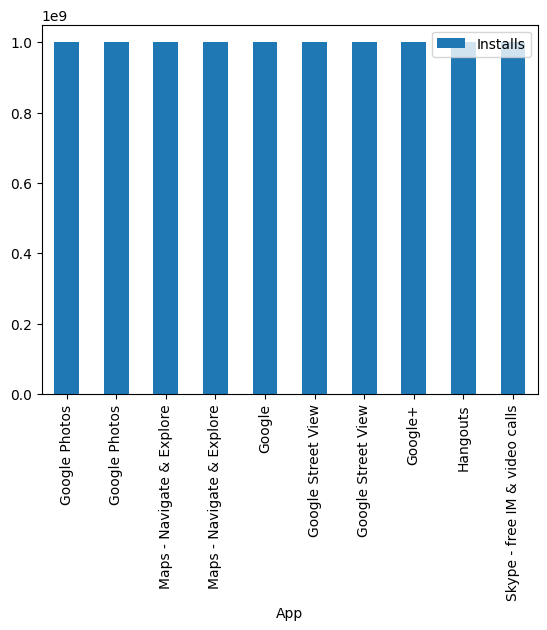

In [50]:
top_apps = df.sort_values("Installs", ascending=False).head(10)
top_apps.plot(x="App", y="Installs", kind="bar")



Purpose:

* Shows **most popular developers**.

---

### -> 2. Scatter Plot

**Reviews vs Rating by Developer**

Purpose:

* Shows **relationship between engagement and quality**.

---

### -> 3. Boxplot

**Ratings distribution by category**

Purpose:

* Shows **which categories developers perform best in**.

---

### -> 4. Pie Chart

**Free vs Paid apps distribution**

Purpose:

* Shows **developer monetization strategies**.

---

### -> 5. Heatmap

**Correlation between installs, rating, reviews, and price**

Purpose:

* Understand relationships between variables.

---

# 5. Insights to Present to the Company

From the analysis you can identify:

* Developers with **highest total installs**
* Developers with **highest average ratings**
* Developers with **strong user engagement**
* Categories where developers are **most successful**

---

# 6. Recommendations

Based on insights, recommend:

1. Collaborate with developers who have **high installs and ratings**.
2. Focus on **categories where successful developers dominate**.
3. Study successful developers' strategies such as:

   * Frequent updates
   * High user ratings
   * Free apps with monetization features.

---

-> **Conclusion:**

To identify the most successful developers, analyze **Installs, Ratings, Reviews, App Category, Price, and App Type**. Use visualizations such as **bar charts, scatter plots, boxplots, and heatmaps** to highlight top developers and patterns in app success. These insights help companies understand **what strategies lead to successful apps on the Play Store**.

### Q17. A marketing research firm wants to analyze the Google Playstore dataset to identify the best time to launch a new app. What features would you analyze to make recommendations to the company, and what data visualizations would you use to present your findings?

Ans:
To identify the best time to launch a new app using the Google Play Store Apps Dataset, the focus should be on analyzing time-related trends and app performance. The dataset contains a useful time feature called Last Updated, which helps understand when apps are released or updated.

## 1. Approach to the Analysis

-> Steps to determine the best launch time:

* Clean and preprocess the dataset

* Extract time features (month/year) from Last Updated

* Analyze installs, ratings, and reviews over time

* Identify months with high user activity and app success

## 2. Features to Analyze

### -> 1. Last Updated

* Indicates when apps were last updated or launched.

* Can be used to extract:
    * Month
    * Year
  
  
Example:



In [51]:
import pandas as pd

df["Last Updated"] = pd.to_datetime(df["Last Updated"])
df["Month"] = df["Last Updated"].dt.month
df["Year"] = df["Last Updated"].dt.year

### -> 2. Installs

* Shows popularity of apps launched during certain periods.

* Helps identify months with higher download activity.

Example:

In [52]:
df.groupby("Month")["Installs"].mean()

,Installs
Month,
1,2.416495e+06
2,1.909871e+06
3,1.778154e+06
4,4.697833e+06
5,6.372511e+06
6,6.430642e+06
7,2.353554e+07
8,4.307928e+07
9,1.465517e+06


### -> 3.Ratings

* Helps determine user satisfaction trends over time.

Example:

In [53]:
df.groupby("Month")["Rating"].mean()

,Rating
Month,
1,4.142892
2,4.096209
3,4.114000
4,4.154600
5,4.161031
6,4.184372
7,4.250141
8,4.293108
9,4.042636


### -> 4. Reviews

* Indicates user engagement levels.

Example:

In [55]:
df["Reviews"] = pd.to_numeric(df["Reviews"], errors="coerce")
df.groupby("Month")["Reviews"].mean()

,Reviews
Month,
1,3.355003e+04
2,5.005330e+04
3,4.255256e+04
4,8.259090e+04
5,1.516767e+05
6,2.575021e+05
7,7.640176e+05
8,1.063730e+06
9,3.036422e+04


### -> 5. Category

* Some categories perform better at specific times of the year.

Example:

* Education apps before school seasons

* Games during holidays

### 3. Data Visualizations to Present Findings

### -> 📊 Line Chart

* Installs over months

<Axes: xlabel='Month'>

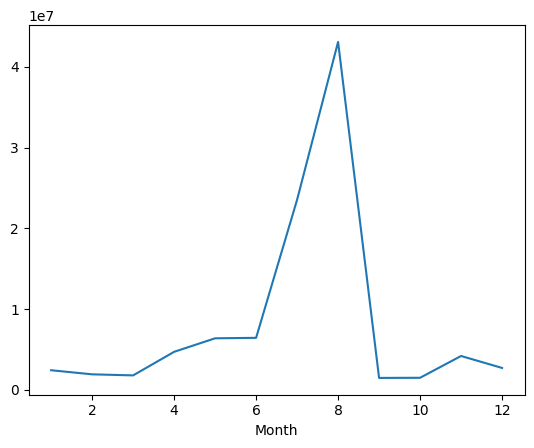

In [56]:
df.groupby("Month")["Installs"].mean().plot(kind="line")

Purpose:
Shows seasonal trends in app downloads.

### -> 📊 Bar Chart

* Average ratings by month

<Axes: xlabel='Month'>

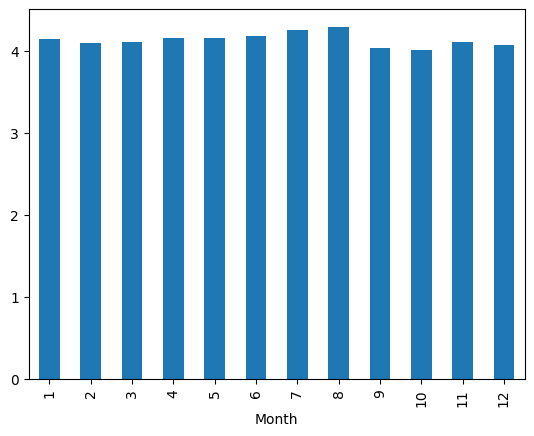

In [57]:
df.groupby("Month")["Rating"].mean().plot(kind="bar")

Purpose:
Shows which months receive higher user satisfaction.

### -> 📈 Scatter Plot

* Reviews vs Installs

<Axes: xlabel='Reviews', ylabel='Installs'>

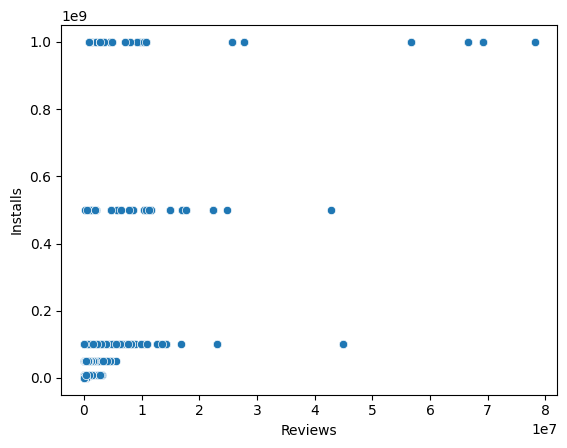

In [58]:
sns.scatterplot(x="Reviews", y="Installs", data=df)

Purpose:
Shows relationship between engagement and popularity.

### -> 🔥 Heatmap:

* Correlation between numeric features

<Axes: >

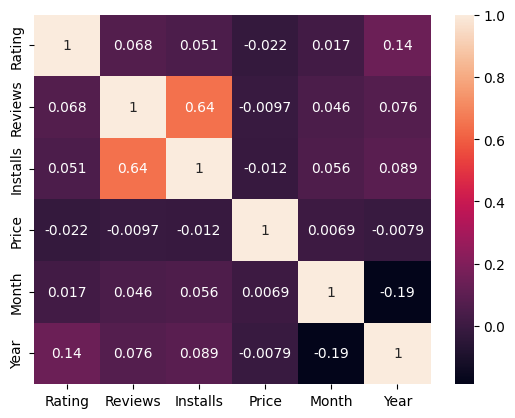

In [60]:
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), annot=True)

Purpose:
Shows relationships between installs, ratings, reviews, and price.

### 4. Insights to Provide

From the analysis, identify:

* Months with highest installs

* Months with highest ratings

* Periods with high user engagement

These indicate optimal app launch windows.


### 5. Final Recommendation

The company should:

* Launch apps during months with high user engagement and installs.

* Avoid periods with low activity or high competition.

* Align launch timing with seasonal demand for specific app categories.

##### To identify the best time to launch an app, I would analyze Last Updated, Installs, Ratings, Reviews, and Category. The Last Updated column can be used to extract monthly trends. Visualizations such as line charts (installs over time), bar charts (ratings by month), scatter plots (reviews vs installs), and heatmaps (feature correlations) can help identify periods with high user activity and engagement, enabling better launch timing recommendations.